In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import load_model

In [4]:
data_train_path  = "C:\\Users\\manis\\OneDrive\\Desktop\\food_image _classifi\\train"
data_test_path = "C:\\Users\\manis\\OneDrive\\Desktop\\food_image _classifi\\test"
data_validation_path = "C:\\Users\\manis\\OneDrive\\Desktop\\food_image _classifi\\validation"

In [5]:
img_height = 200
img_width = 200

In [6]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_height, img_width),
    batch_size=32,
    validation_split=False
)

Found 161 files belonging to 11 classes.


In [7]:
data_cat = data_train.class_names
print(data_cat)

['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles- pasta', 'Rice', 'Soup', 'Vegetable-Fruits', 'seafood']


In [8]:
data_cat

['Bread',
 'Dairy product',
 'Dessert',
 'Egg',
 'Fried food',
 'Meat',
 'Noodles- pasta',
 'Rice',
 'Soup',
 'Vegetable-Fruits',
 'seafood']

In [9]:
data_validation = tf.keras.utils.image_dataset_from_directory(
    data_validation_path,
    image_size=(img_height, img_width),
    batch_size=32,
    shuffle=False,
    validation_split=False
    
)

Found 161 files belonging to 11 classes.


In [10]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 162 files belonging to 11 classes.


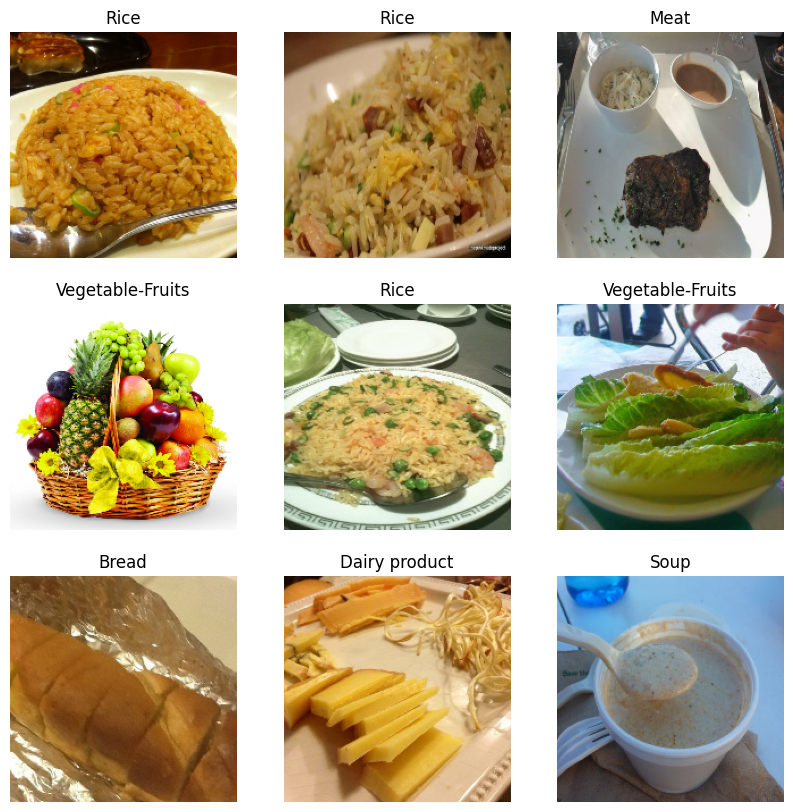

In [11]:
plt.figure(figsize=(10,10))

for images, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis("off")

In [12]:
from tensorflow.keras.models import Sequential

In [13]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [14]:
model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(units = len (data_cat))
])

In [15]:
model = tf.keras.Sequential([

    tf.keras.Input(shape=(img_height, img_width, 3)),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(data_cat))
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
epochs_size = 25

history = model.fit(
    data_train,
    validation_data=data_validation,
    epochs=epochs_size
)

Epoch 1/25


6/6 [==============================] - 5s 572ms/step - loss: 9.2384 - accuracy: 0.0932 - val_loss: 8.5803 - val_accuracy: 0.0807
Epoch 2/25
6/6 [==============================] - 3s 427ms/step - loss: 8.5283 - accuracy: 0.1056 - val_loss: 12.4022 - val_accuracy: 0.1056
Epoch 3/25
6/6 [==============================] - 3s 469ms/step - loss: 12.5670 - accuracy: 0.1056 - val_loss: 13.8082 - val_accuracy: 0.1056
Epoch 4/25
6/6 [==============================] - 3s 479ms/step - loss: 13.8079 - accuracy: 0.1056 - val_loss: 13.8079 - val_accuracy: 0.1056
Epoch 5/25
6/6 [==============================] - 2s 361ms/step - loss: 13.8079 - accuracy: 0.1056 - val_loss: 13.8079 - val_accuracy: 0.1056
Epoch 6/25
6/6 [==============================] - 3s 411ms/step - loss: 13.8079 - accuracy: 0.1056 - val_loss: 13.8079 - val_accuracy: 0.1056
Epoch 7/25
6/6 [==============================] - 2s 357ms/step - loss: 13.8079 - accuracy: 0.1056 - val_loss: 13.8079 - val_accuracy: 0.1056
Epoch 8

Text(0.5, 1.0, 'loss')

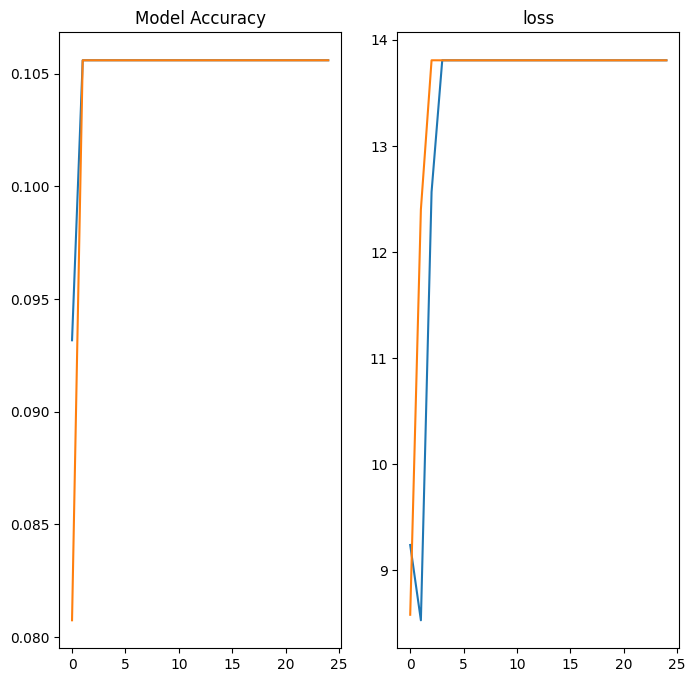

In [18]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label='train_acc')
plt.plot(epochs_range,history.history['val_accuracy'],label='val_acc')
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label='train_loss')
plt.plot(epochs_range,history.history['val_loss'],label='val_loss')
plt.title('loss')



In [19]:
image= r"C:\Users\manis\OneDrive\Desktop\food_image _classifi\Apple.jpg"
img = tf.keras.utils.load_img(image, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_batch = tf.expand_dims(img_array, 0)

In [20]:
predict = model.predict(img_batch)

1/1 [==============================] - 0s 196ms/step


In [21]:
score = tf.nn.softmax(predict)

In [22]:
print('Veg/Fruit in image is {} with accuracy of {:.2f}%'.format(
    data_cat[np.argmax(score)],
    np.max(score) * 100
))

Veg/Fruit in image is Egg with accuracy of 100.00%


In [24]:
model.save("model.h5")

c:\Users\manis\OneDrive\Desktop\food_image _classifi\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
